In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv, global_mean_pool
import pandas as pd
import numpy as np
import pickle
import json
from rdkit import Chem
from rdkit.Chem import rdchem
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, accuracy_score,
                             classification_report)
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch Geometric ready")

Device: cpu
PyTorch Geometric ready


In [2]:
# reload everything
with open('../data/davis_drugs.txt', 'rb') as f:
    drugs = list(json.loads(f.read().decode('utf-8', errors='ignore')).values())

with open('../data/davis_proteins.txt', 'rb') as f:
    proteins = list(json.loads(f.read().decode('utf-8', errors='ignore')).values())

with open('../data/davis_affinity.npy', 'rb') as f:
    affinity = np.array(pickle.load(f, encoding='latin1'))

with open('../data/drug_graphs.pkl', 'rb') as f:
    saved = pickle.load(f)
    graphs = saved['graphs']
    valid_indices = saved['valid_indices']

df = pd.read_csv('../data/dti_pairs.csv')

print(f"Drugs: {len(drugs)}")
print(f"Proteins: {len(proteins)}")
print(f"Graphs: {len(graphs)}")
print(f"Pairs: {len(df)}")
print(f"Positive: {df['label'].sum()} ({df['label'].mean()*100:.1f}%)")

C:\Users\hidey\AppData\Local\Temp\ipykernel_42368\3422865058.py:9: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  affinity = np.array(pickle.load(f, encoding='latin1'))


Drugs: 68
Proteins: 442
Graphs: 68
Pairs: 30056
Positive: 1527 (5.1%)


In [3]:
from torch_geometric.data import Dataset as PyGDataset

class DTIDataset(PyGDataset):
    def __init__(self, pairs_df, graphs, valid_indices):
        super().__init__()
        self.pairs = pairs_df.reset_index(drop=True)
        self.graphs = graphs
        # map original drug index to graph index
        self.idx_map = {orig: new for new, orig 
                        in enumerate(valid_indices)}

    def len(self):
        return len(self.pairs)

    def get(self, idx):
        row = self.pairs.iloc[idx]
        drug_idx = int(row['drug_idx'])
        graph_idx = self.idx_map[drug_idx]
        
        # get molecular graph
        mol_graph = self.graphs[graph_idx]
        
        # create new Data object with label
        data = Data(
            x=mol_graph.x,
            edge_index=mol_graph.edge_index,
            edge_attr=mol_graph.edge_attr,
            y=torch.tensor([int(row['label'])], dtype=torch.float)
        )
        return data

# train/val/test split
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} pairs")
print(f"Val:   {len(val_df)} pairs")
print(f"Test:  {len(test_df)} pairs")

# create datasets
train_dataset = DTIDataset(train_df, graphs, valid_indices)
val_dataset   = DTIDataset(val_df,   graphs, valid_indices)
test_dataset  = DTIDataset(test_df,  graphs, valid_indices)

# create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# test one batch
batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  x shape:          {batch.x.shape}")
print(f"  edge_index shape: {batch.edge_index.shape}")
print(f"  y shape:          {batch.y.shape}")

Train: 21039 pairs
Val:   4508 pairs
Test:  4509 pairs

Train batches: 329
Val batches:   71
Test batches:  71


C:\Users\hidey\AppData\Local\Temp\ipykernel_42368\1043475828.py:52: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
C:\Users\hidey\AppData\Local\Temp\ipykernel_42368\1043475828.py:53: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
C:\Users\hidey\AppData\Local\Temp\ipykernel_42368\1043475828.py:54: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)



Sample batch:
  x shape:          torch.Size([1969, 76])
  edge_index shape: torch.Size([2, 4332])
  y shape:          torch.Size([64])


In [4]:
from torch_geometric.loader import DataLoader as PyGDataLoader

# fix the dataloaders
train_loader = PyGDataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = PyGDataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = PyGDataLoader(test_dataset,  batch_size=64, shuffle=False)

# ── GAT model ──────────────────────────────────────────────────────────
class GATModel(nn.Module):
    def __init__(self, node_features=76, hidden=64, 
                 heads=8, dropout=0.3):
        super().__init__()
        
        # GAT layers
        self.conv1 = GATConv(node_features, hidden, 
                             heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden * heads, hidden, 
                             heads=heads, dropout=dropout)
        self.conv3 = GATConv(hidden * heads, hidden, 
                             heads=1, dropout=dropout)
        
        # classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        # GAT layers with ELU activation
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.conv3(x, edge_index))
        
        # global pooling — aggregate all atom features
        x = global_mean_pool(x, batch)
        
        # classify
        return self.classifier(x).squeeze(1)

# create model
model = GATModel(node_features=76).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"GAT model ready")
print(f"Total parameters: {total_params:,}")
print(f"\nArchitecture:")
print(model)

GAT model ready
Total parameters: 353,729

Architecture:
GATModel(
  (conv1): GATConv(76, 64, heads=8)
  (conv2): GATConv(512, 64, heads=8)
  (conv3): GATConv(512, 64, heads=1)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [5]:
# class weights for imbalanced dataset
pos_weight = torch.tensor(
    [(1-df['label'].mean()) / df['label'].mean()]
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5, factor=0.5)

def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y)
            
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            total_loss += loss.item()
            probs = torch.sigmoid(out).cpu().detach().numpy()
            preds = (probs > 0.5).astype(int)
            labels = batch.y.cpu().numpy().astype(int)
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels)
    
    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, auc

# training
best_auc = 0
history = []
epochs = 50

print(f"Training GAT on {len(train_df)} pairs...")
print(f"\n{'Ep':>3} {'TLoss':>7} {'TAcc':>6} {'TAUC':>6} "
      f"{'VLoss':>7} {'VAcc':>6} {'VAUC':>6}")
print("-" * 48)

for ep in range(epochs):
    tl, ta, tauc = run_epoch(model, train_loader, 
                             criterion, optimizer)
    vl, va, vauc = run_epoch(model, val_loader, criterion)
    scheduler.step(vauc)
    history.append([tl, ta, tauc, vl, va, vauc])
    
    flag = ''
    if vauc > best_auc:
        best_auc = vauc
        torch.save(model.state_dict(), '../data/gat_model.pth')
        flag = ' ✓'
    
    if (ep + 1) % 5 == 0:
        print(f"{ep+1:>3} {tl:>7.4f} {ta:>6.3f} {tauc:>6.4f} "
              f"{vl:>7.4f} {va:>6.3f} {vauc:>6.4f}{flag}")

print(f"\nBest validation AUC: {best_auc:.4f}")
print(f"Model saved to data/gat_model.pth")

Training GAT on 21039 pairs...

 Ep   TLoss   TAcc   TAUC   VLoss   VAcc   VAUC
------------------------------------------------
  5  1.1415  0.723 0.7403  1.1547  0.780 0.7411 ✓
 10  1.0955  0.724 0.7655  1.1177  0.804 0.7616 ✓


KeyboardInterrupt: 

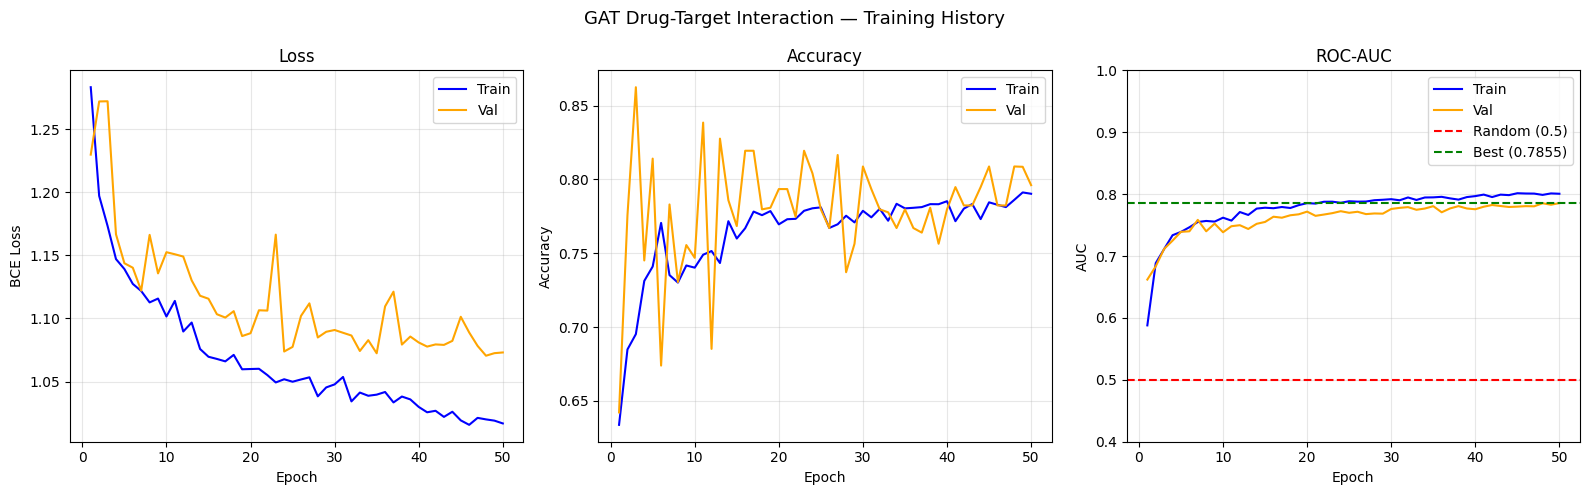

In [3]:
import json
import matplotlib.pyplot as plt
import numpy as np

# load history from Colab training
with open('../docs/gat_history.json', 'r') as f:
    history_data = json.load(f)

history = history_data['history']
best_auc = history_data['best_auc']

epochs_x = list(range(1, len(history) + 1))
train_loss = [h[0] for h in history]
train_acc  = [h[1] for h in history]
train_auc  = [h[2] for h in history]
val_loss   = [h[3] for h in history]
val_acc    = [h[4] for h in history]
val_auc    = [h[5] for h in history]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# loss
axes[0].plot(epochs_x, train_loss, label='Train', color='blue')
axes[0].plot(epochs_x, val_loss, label='Val', color='orange')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# accuracy
axes[1].plot(epochs_x, train_acc, label='Train', color='blue')
axes[1].plot(epochs_x, val_acc, label='Val', color='orange')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(epochs_x, train_auc, label='Train', color='blue')
axes[2].plot(epochs_x, val_auc, label='Val', color='orange')
axes[2].axhline(y=0.5, color='red', linestyle='--', 
                label='Random (0.5)', linewidth=1.5)
axes[2].axhline(y=best_auc, color='green', linestyle='--',
                label=f'Best ({best_auc:.4f})', linewidth=1.5)
axes[2].set_title('ROC-AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].set_ylim(0.4, 1.0)

plt.suptitle('GAT Drug-Target Interaction — Training History', 
             fontsize=13)
plt.tight_layout()
plt.show()